# Cuaderno de visualización de variables a estudiar

Este cuaderno Jupyter busca visualizar las variables a estudiar. De esta forma, podemos buscar relaciones entre estas (al menos, a primera vista) antes de comenzar a realizar pruebas más exhaustivas y exactas. El objetivo es discriminar métodos y relaciones a explorar en función del comportamiento aparente de estas variables.

## Lecturas de los piranómetros y células calibradas

Uno de los objetivos de este estudio es comprobar si es posible sustituir la instalación de piranómetros (que tienen un alto coste) utilizando otros sensores de irradiancia como células calibradas o simples placas monofaciales.

### Comprobación de la sustitubilidad directa de las mediciones

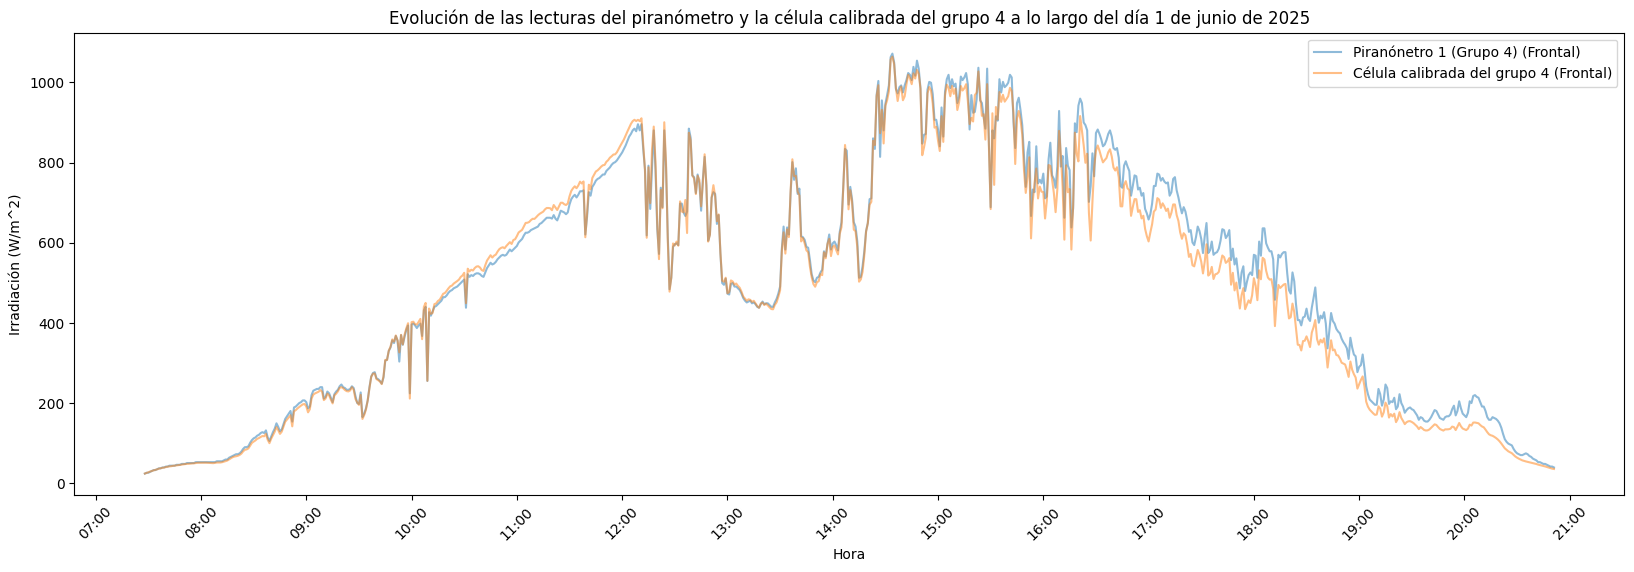

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt
import pandas as pd

# Importo los datos desde el fichero CSV
df = pd.DataFrame(pd.read_csv('in/unificado.csv'))
# Convierto la columna Datetime a formato datetime
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Elimino las filas con valores nulos en la columna 'PIR F1'
df = df.dropna(subset=['PIR F1'], how='any')

df = df[(df['Datetime'].dt.day == 1) & (df['Datetime'].dt.month == 6) & (df['Datetime'].dt.year == 2025)]

# Hago un plot de las lecturas del piranómetro y la célula calibrada a lo largo de un día completo
df.index = df['Datetime']

fig, ax = plt.subplots(figsize=(20, 6))

ax.plot(df.index, df['PIR F1'], label='Piranónetro 1 (Grupo 4) (Frontal)', alpha=0.5)
ax.plot(df.index, df['G FRONT'], label='Célula calibrada del grupo 4 (Frontal)', alpha=0.5)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:00'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))

ax.set_xlabel('Hora')
ax.set_ylabel('Irradiación (W/m^2)')
ax.set_title('Evolución de las lecturas del piranómetro y la célula calibrada del grupo 4 a lo largo del día 1 de junio de 2025')
ax.legend()
plt.xticks(rotation=45)
plt.show()

Para comprobar si nuestras sospechas de que la célula calibrada hace la misma medición que el piranómetro, calculamos la significancia estadística de la diferencia entre las series utilizando la correlación de Pearson.

Valor p de la regresión lineal: 0.00000
La correlación es estadísticamente significativa.
Coeficiente de correlación de Pearson: 0.99339


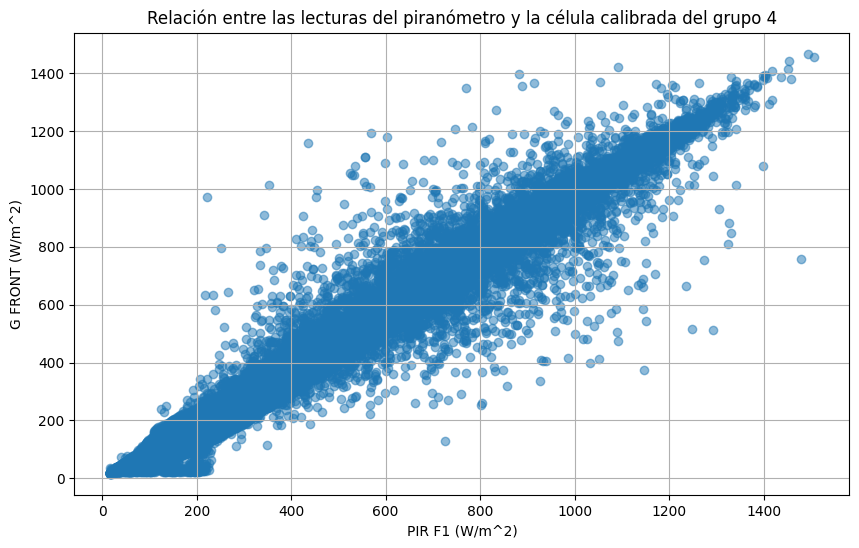

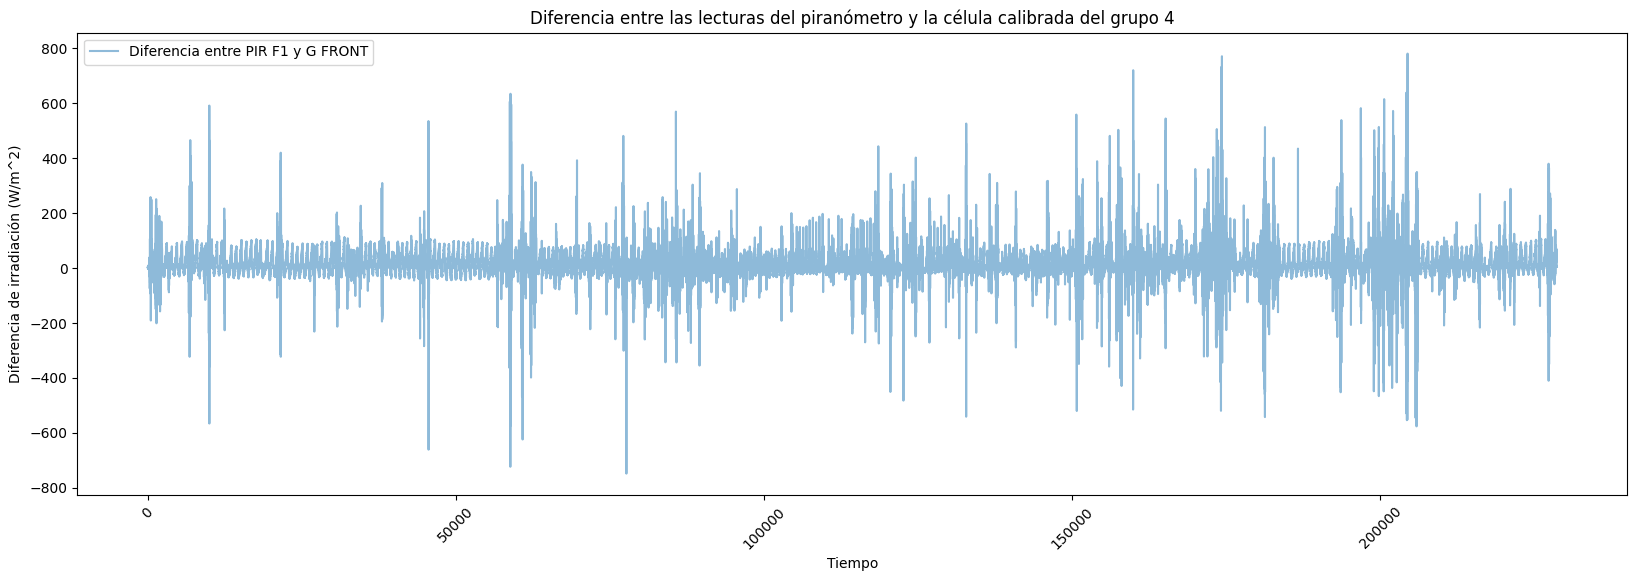

In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt
import pandas as pd

# Importo los datos desde el fichero CSV
df = pd.DataFrame(pd.read_csv('in/unificado.csv'))
# Convierto la columna Datetime a formato datetime
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Elimino las filas con valores nulos en la columna 'PIR F1' y 'G FRONT'
df = df.dropna(subset=['PIR F1', 'G FRONT'], how='any')

from scipy.stats import linregress

# Calculo la regresión lineal para obtener el valor p y determinar si existe relación lineal entre las dos variables
p_valor = linregress(df['PIR F1'], df['G FRONT'])[3]
print(f"Valor p de la regresión lineal: {p_valor:.5f}")

if p_valor < 0.05:
    print("La correlación es estadísticamente significativa.")
    
    # Calculo el coeficiente de correlación de Pearson si hay relación lineal significativa
    pearson = df['PIR F1'].corr(df['G FRONT'])
    print(f"Coeficiente de correlación de Pearson: {pearson:.5f}")
    
else:
    print("La correlación no es estadísticamente significativa.")
    
# Grafico un scatter plot para visualizar la relación entre las lecturas del piranómetro y la célula calibrada
plt.figure(figsize=(10, 6))
plt.scatter(df['PIR F1'], df['G FRONT'], alpha=0.5)
plt.xlabel('PIR F1 (W/m^2)')
plt.ylabel('G FRONT (W/m^2)')
plt.title('Relación entre las lecturas del piranómetro y la célula calibrada del grupo 4')
plt.grid()
plt.show()

# Grafico la línea de diferencia entre las lecturas del piranómetro y la célula calibrada a lo largo del día
df['Diferencia'] = df['PIR F1'] - df['G FRONT']
fig, ax = plt.subplots(figsize=(20, 6))
ax.plot(df.index, df['Diferencia'], label='Diferencia entre PIR F1 y G FRONT', alpha=0.5)
ax.set_xlabel('Tiempo')
ax.set_ylabel('Diferencia de irradiación (W/m^2)')
ax.set_title('Diferencia entre las lecturas del piranómetro y la célula calibrada del grupo 4')
ax.legend()
plt.xticks(rotation=45)
plt.show()

Para demostrar finalmente que ambas variables son iguales, haremos un análisis de diferencias Bland Altman.

Las diferencias no siguen una distribución normal (p-value: 0.01000).
Límite inferior de acuerdo: -60.27123 W/m^2
Límite superior de acuerdo: 89.49037 W/m^2
Margen de error para el sesgo: 0.15349 W/m^2
La línea de igualdad (y=0) no está dentro del intervalo de confianza del sesgo, por lo que el sesgo es estadísticamente significativo.


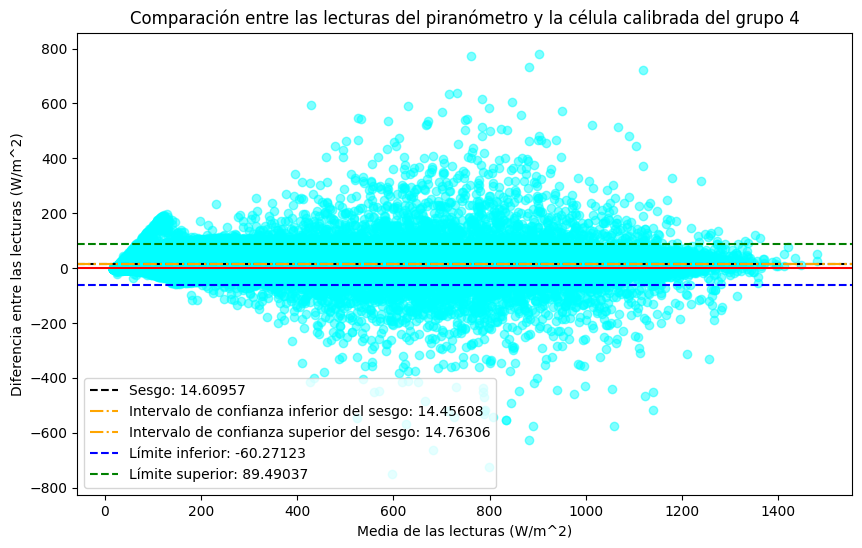

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Importo los datos desde el fichero CSV
df = pd.DataFrame(pd.read_csv('in/unificado.csv'))
# Convierto la columna Datetime a formato datetime
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Elimino las filas con valores nulos en la columna 'PIR F1' y 'G FRONT'
df = df.dropna(subset=['PIR F1', 'G FRONT'], how='any')

def bland_altman(serie1: pd.Series, serie2: pd.Series, df: pd.DataFrame, nombre_serie1: str, nombre_serie2: str, nombre_serie1_unidad: str, nombre_serie2_unidad: str, nombre_prueba: str):
    d = []
    m = []
    sesgo = 0

    # Calculo los vectores de diferencias y de media 
    for i in range(len(df)):
        d.append(serie1.iloc[i] - serie2.iloc[i])
        m.append((serie1.iloc[i] + serie2.iloc[i]) / 2)
        sesgo += d[i]
        
    sesgo /= len(df)    # Calculo el sesgo como la media de las diferencias

    # Verifico normalidad con el test de Anderson-Darling porque la muestra es demasiado grande para Shapiro
    from scipy.stats import anderson

    resultado = anderson(d, dist='norm', method='interpolate')

    if resultado.pvalue < 0.05:
        print(f"Las diferencias no siguen una distribución normal (p-value: {resultado.pvalue:.5f}).")
        normal = False
    else:
        print(f"Las diferencias siguen una distribución normal (p-value: {resultado.pvalue:.5f}).")
        normal = True
        
    # Sabiendo si las diferencias siguen una distribución normal o no, calculo los límites de acuerdo
    if normal:
        coef = 1.96
    else:
        coef = 2
        
    media = sesgo
    std_d = pd.Series(d).std()    

    lim_inf, lim_sup = media - coef * (std_d), media + coef * (std_d)

    print(f"Límite inferior de acuerdo: {lim_inf:.5f} W/m^2")
    print(f"Límite superior de acuerdo: {lim_sup:.5f} W/m^2")

    confianza = 0.95
    n = len(d)
    margen_error_sesgo = 1.96 * (std_d / (n ** 0.5))    # Margen de error para el sesgo (media)
    print(f"Margen de error para el sesgo: {margen_error_sesgo:.5f} W/m^2")

    if sesgo - margen_error_sesgo > 0 or sesgo + margen_error_sesgo < 0:
        print("La línea de igualdad (y=0) no está dentro del intervalo de confianza del sesgo, por lo que el sesgo es estadísticamente significativo.")
    else:
        print("La línea de igualdad (y=0) está dentro del intervalo de confianza del sesgo, por lo que el sesgo no es estadísticamente significativo.")

    # Muestro la diferencia frente a la media en un gráfico de dispersión
    plt.figure(figsize=(10, 6))
    plt.scatter(m, d, color='cyan', alpha=0.5)
    plt.axhline(0, color='red', linestyle='-')                                                      # Línea de referencia en 0
    plt.axhline(sesgo, color='black', linestyle='--', label=f'Sesgo: {sesgo:.5f}')                  # Línea del sesgo
    plt.axhline(sesgo - margen_error_sesgo, color='orange', linestyle='-.', label=f'Intervalo de confianza inferior del sesgo: {sesgo - margen_error_sesgo:.5f}')    # Línea del límite inferior del intervalo de confianza del sesgo
    plt.axhline(sesgo + margen_error_sesgo, color='orange', linestyle='-.', label=f'Intervalo de confianza superior del sesgo: {sesgo + margen_error_sesgo:.5f}')    # Línea del límite superior del intervalo de confianza del sesgo
    plt.axhline(lim_inf, color='blue', linestyle='--', label=f'Límite inferior: {lim_inf:.5f}')     # Línea del límite inferior de acuerdo
    plt.axhline(lim_sup, color='green', linestyle='--', label=f'Límite superior: {lim_sup:.5f}')    # Línea del límite superior de acuerdo
    plt.xlabel(f'Media de las lecturas ({nombre_serie1_unidad})')
    plt.ylabel(f'Diferencia entre las lecturas ({nombre_serie2_unidad})')
    plt.title(nombre_prueba)
    plt.legend()
    plt.show()

bland_altman(df['PIR F1'], df['G FRONT'], df, 'PIR F1', 'G FRONT', 'W/m^2', 'W/m^2', 'Comparación entre las lecturas del piranómetro y la célula calibrada del grupo 4')

### Tras comprobar que las mediciones no son sustituibles

Dado que las mediciones no son directamente sustituibles pero sí están fuertemente correlacionadas, podemos intentar encontrar una relación entre ambas variables.

#### Modelo de regresión lineal

En primer lugar, por simplicidad, se intentará hacer una regresión lineal entre ambas variables.

Resultados de la regresión lineal entre las lecturas del piranómetro y la célula calibrada del grupo 4:
Pendiente: 0.99861
Ordenada en el origen: -13.89265
Coeficiente de correlación de Pearson: 0.99339
Valor p de la regresión lineal: 0.00000
Error estándar de la pendiente: 0.00024
La correlación es estadísticamente significativa.

Resultados de Bland-Altman entre las predicciones de la regresión lineal y las lecturas reales del piranómetro:
Las diferencias no siguen una distribución normal (p-value: 0.01000).
Límite inferior de acuerdo: -103.99171 W/m^2
Límite superior de acuerdo: 45.59410 W/m^2
Margen de error para el sesgo: 0.15331 W/m^2
La línea de igualdad (y=0) no está dentro del intervalo de confianza del sesgo, por lo que el sesgo es estadísticamente significativo.


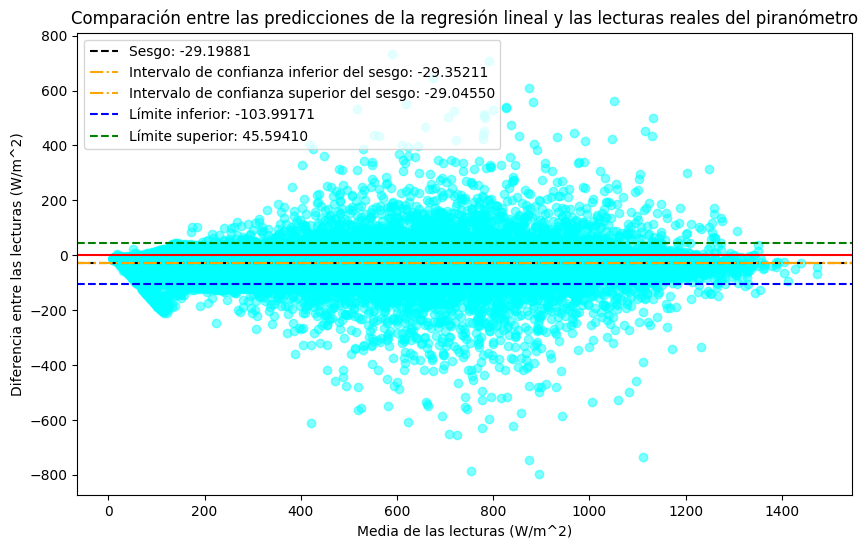

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt
import pandas as pd

# Importo los datos desde el fichero CSV
df = pd.DataFrame(pd.read_csv('in/unificado.csv'))
# Convierto la columna Datetime a formato datetime
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Elimino las filas con valores nulos en la columna 'PIR F1' y 'G FRONT'
df = df.dropna(subset=['PIR F1', 'G FRONT'], how='any')

from scipy.stats import linregress

# Calculo la regresión lineal para obtener el valor p y determinar si existe relación lineal entre las dos variables
resultado = linregress(df['PIR F1'], df['G FRONT'])

# Saco la pendiente, la ordenada en el origen, el coeficiente de correlación de Pearson y el valor p
pendiente, ordenada, pearson, p_valor, error_estandar = resultado

print(f"Resultados de la regresión lineal entre las lecturas del piranómetro y la célula calibrada del grupo 4:")
print(f"Pendiente: {pendiente:.5f}")
print(f"Ordenada en el origen: {ordenada:.5f}")
print(f"Coeficiente de correlación de Pearson: {pearson:.5f}")
print(f"Valor p de la regresión lineal: {p_valor:.5f}")
print(f"Error estándar de la pendiente: {error_estandar:.5f}")

if p_valor < 0.05:
    print("La correlación es estadísticamente significativa.")

# Si es estadísticamente significativa, compruebo que la predicción hecha por la regresión lineal se ajusta a los datos reales del piranómemtro con un Bland Altman entre las predicciones de la regresión lineal y las lecturas reales del piranómetro. Para ello, calculo las predicciones de la regresión lineal para cada lectura del piranómetro y luego hago un gráfico de Bland-Altman entre estas predicciones y las lecturas reales del piranómetro.
prediccion = pendiente * df['G FRONT'] + ordenada
print(f"\nResultados de Bland-Altman entre las predicciones de la regresión lineal y las lecturas reales del piranómetro:")
bland_altman(prediccion, df['PIR F1'], df, 'Predicción de la regresión lineal', 'Lecturas reales del piranómetro', 'W/m^2', 'W/m^2', 'Comparación entre las predicciones de la regresión lineal y las lecturas reales del piranómetro')

#### Regresión simbólica

Dado que la relación entre ambas variables no es lineal, se intentará encontrar una relación entre ambas empleando regresión simbólica. Para ello, se empleará el algoritmo de regresión simbólica para intentar buscar relaciones.

In [1]:
import pandas as pd
import datetime as dt

from pysr import PySRRegressor
# Cargamos el dataframe
df = pd.DataFrame(pd.read_csv('in/unificado.csv'))
# Convierto la columna Datetime a formato datetime
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Elimino las filas con valores nulos en la columna 'PIR F1' y 'G FRONT'
df = df.dropna(subset=['PIR F1', 'G FRONT'], how='any')

# =*=*=*=*=*=*=*=*| Constantes de configuración del modelo |*=*=*=*=*=*=*=*=
ITERACIONES = 10                                        # Número de iteraciones para el entrenamiento del modelo de regresión simbólica
OPERADORES_BINARIOS = ["+", "-", "*", "/"]              # Operadores binarios permitidos en las fórmulas
OPERADORES_UNARIOS = []                                 # No se emplean operadores unarios
SELECCION = "best"                                      # Método de selección del modelo (el mejor modelo encontrado)
FUNCION_PERDIDA = "loss(x, y) = (x - y)^2"              # Función de pérdida a minimizar (error cuadrático medio)
TAM_MAXIMO = 20                                         # Tamaño máximo de las fórmulas
TAM_POBLACION = 20                                      # Tamaño de la población de fórmulas en cada iteración
RANDOM_STATE = 1234                                     # Semilla para la generación de números aleatorios (para reproducibilidad)
# =*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=


# Genero el modeo de regresión simbólica
model = PySRRegressor(
    niterations=ITERACIONES,
    binary_operators=OPERADORES_BINARIOS,
    unary_operators=OPERADORES_UNARIOS,
    model_selection=SELECCION,
    elementwise_loss=FUNCION_PERDIDA,
    maxsize=TAM_MAXIMO,
    population_size=TAM_POBLACION,
    random_state=RANDOM_STATE,
    deterministic=True,
    parallelism='serial'
)

# Entreno el modelo con las lecturas de la célula calibrada como variable independiente y las lecturas del piranómetro como variable dependiente
model.fit(df['G FRONT'].values.reshape(-1, 1), df['PIR F1'].values)

# Muestro las mejores fórmulas encontradas por el modelo
print("Mejores fórmulas encontradas por el modelo de regresión simbólica:")
print(model)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


/home/jcarvic/Documentos/Universidad/Extracurriculares/codigo/.venv/lib64/python3.13/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/jcarvic/Documentos/Universidad/Extracurriculares/codigo/.venv/lib64/python3.13/site-packages/pysr/sr.py:2265: UserWarning: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (https://ai.damtp.cam.ac.uk/pysr/options/#batching). You should also reconsider if you need that many datapoints. Unless you have a large amount of noise (in which case you should smooth your dataset first), generally < 10,000 datapoints is enough to find a functional form with symbolic regression. More datapoints will lower the search speed.
  warnings.warn(
Compiling Julia backend...
[ Info: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (`options.batching`), and also if you need that man


Expressions evaluated per second: 1.560e+03
Progress: 13 / 310 total iterations (4.194%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.726e+05  0.000e+00  y = -2.0511
3           1.402e+03  2.775e+00  y = x₀ + 14.611
5           1.402e+03  -0.000e+00  y = (x₀ - -11.964) + 2.651
9           1.387e+03  2.626e-03  y = ((x₀ * -0.011805) - -7.0154) + (x₀ + 13.502)
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 1.560e+03
Progress: 23 / 310 total iterations (7.419%)
══════════════════════════════════════════════════════════════════════════════════

[ Info: Final population:
[ Info: Results saved to:


Mejores fórmulas encontradas por el modelo de regresión simbólica:
PySRRegressor.equations_ = [
	   pick         score                                           equation  \
	0        0.000000e+00                                                 x0   
	1  >>>>  7.086424e-02                                     x0 + 14.608181   
	2        5.314470e-03                      (x0 - -20.758053) * 0.9881983   
	3        1.802508e-08   (((x0 + 5.007135) - -5.310448) * 1.9881996) - x0   
	4        5.915363e-04  (x0 * (-9.103783e-5 - (-1.0906337 / x0))) * (x...   
	5        6.496321e-03  (x0 / (1.2074207 / ((x0 * -6.289412e-5) - -0.0...   
	6        1.973895e-03  x0 + ((((x0 + 215.63559) * x0) / (x0 - -161.17...   
	7        2.955130e-06  ((((((x0 + 81.65336) - -95.117355) + 47.83801)...   
	
	        loss  complexity  
	0  1615.2168           1  
	1  1401.7770           3  
	2  1386.9565           5  
	3  1386.9564           9  
	4  1385.3165          11  
	5  1367.4340          13  
	6  1362.0463


Resultados de Bland-Altman entre las predicciones de la regresión simbólica y las lecturas reales del piranómetro:
Las diferencias no siguen una distribución normal (p-value: 0.01000).
Límite inferior de acuerdo: -74.88219 W/m^2
Límite superior de acuerdo: 74.87941 W/m^2
Margen de error para el sesgo: 0.15349 W/m^2
La línea de igualdad (y=0) está dentro del intervalo de confianza del sesgo, por lo que el sesgo no es estadísticamente significativo.


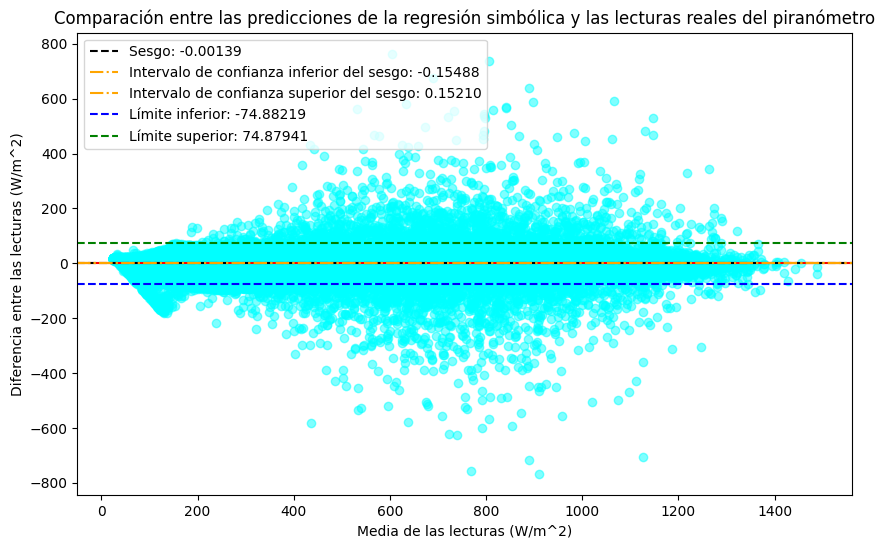

In [4]:
import pandas as pd
import datetime as dt

# Cargamos el dataframe
df = pd.DataFrame(pd.read_csv('in/unificado.csv'))
# Convierto la columna Datetime a formato datetime
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Elimino las filas con valores nulos en la columna 'PIR F1' y 'G FRONT'
df = df.dropna(subset=['PIR F1', 'G FRONT'], how='any')

prediccion = 1 * df['G FRONT'] + 14.608181
print(f"\nResultados de Bland-Altman entre las predicciones de la regresión simbólica y las lecturas reales del piranómetro:")
bland_altman(prediccion, df['PIR F1'], df, 'Predicción de la regresión simbólica', 'Lecturas reales del piranómetro', 'W/m^2', 'W/m^2', 'Comparación entre las predicciones de la regresión simbólica y las lecturas reales del piranómetro')

#### Árbol CART

Dado que la correlación entre variables es fuerte pero no lineal, se intentará encontrar una relación entre ambas empleando un árbol de decisión CART.

Árbol obtenido:


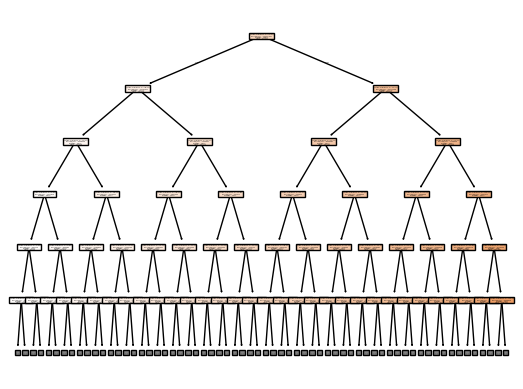


Resultados de Bland-Altman entre las predicciones del modelo de árbol de decisión CART y las lecturas reales del piranómetro:
Las diferencias no siguen una distribución normal (p-value: 0.01000).
Límite inferior de acuerdo: -70.70561 W/m^2
Límite superior de acuerdo: 70.70561 W/m^2
Margen de error para el sesgo: 0.14493 W/m^2
La línea de igualdad (y=0) está dentro del intervalo de confianza del sesgo, por lo que el sesgo no es estadísticamente significativo.


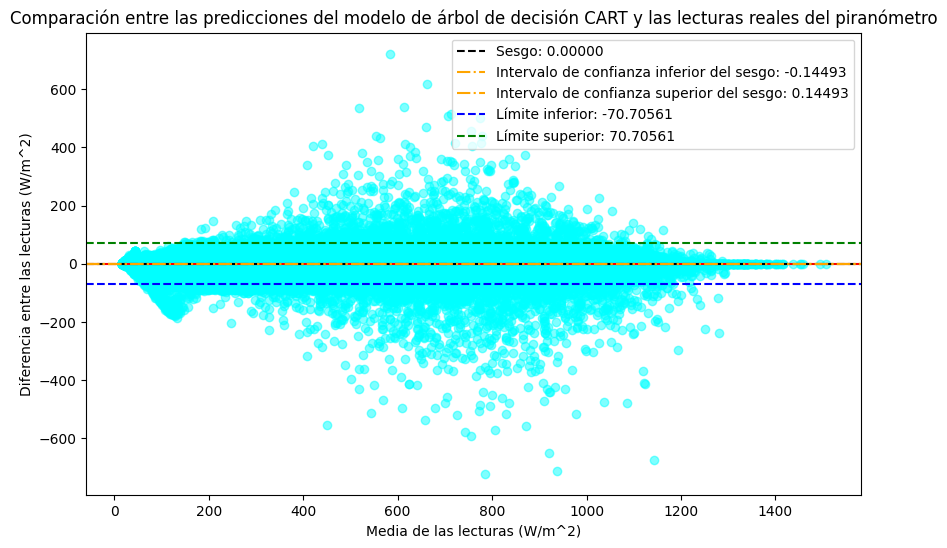

In [6]:
import pandas as pd
import datetime as dt

# Cargamos el dataframe
df = pd.DataFrame(pd.read_csv('in/unificado.csv'))
# Convierto la columna Datetime a formato datetime
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Elimino las filas con valores nulos en la columna 'PIR F1' y 'G FRONT'
df = df.dropna(subset=['PIR F1', 'G FRONT'], how='any')

from sklearn import tree

modelo = tree.DecisionTreeRegressor()
predictor = modelo.fit(df['G FRONT'].values.reshape(-1, 1), df['PIR F1'].values)

# Hago las predicciones del modelo de árbol de decisión CART para cada lectura de la célula calibrada
prediccion_cart = predictor.predict(df['G FRONT'].values.reshape(-1, 1))

print(f"Árbol obtenido:")
tree.plot_tree(predictor, feature_names=['Lectura de G FRONT'], filled=True, max_depth=5)
plt.savefig('out/arbol_decision.png', dpi=1200)
plt.show()

# Convierto las predicciones a un formato de serie de pandas para poder hacer el Bland-Altman
prediccion_cart = pd.Series(prediccion_cart)

# Hago un Bland-Altman entre las predicciones del modelo de árbol de decisión CART y las lecturas reales del piranómetro
print(f"\nResultados de Bland-Altman entre las predicciones del modelo de árbol de decisión CART y las lecturas reales del piranómetro:")
bland_altman(prediccion_cart, df['PIR F1'], df, 'Predicción del modelo de árbol de decisión CART', 'Lecturas reales del piranómetro', 'W/m^2', 'W/m^2', 'Comparación entre las predicciones del modelo de árbol de decisión CART y las lecturas reales del piranómetro')